In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available.")

CUDA available: True
GPU: Tesla T4


In [ ]:
!pip install -q transformers datasets evaluate accelerate pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.8 MB/s eta 0:00:00


In [93]:
import os
import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import Dataset

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from scipy.special import softmax

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)

# Display settings
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
import joblib

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving X_test.parquet to X_test.parquet
Saving X_train.parquet to X_train.parquet
Saving y_test.parquet to y_test.parquet
Saving y_train.parquet to y_train.parquet


In [ ]:
print(os.listdir("/content"))

['.config', 'drive', 'y_test.parquet', 'y_train.parquet', 'X_test.parquet', 'X_train.parquet', 'sample_data']


In [118]:
# load train and test datasets
X_train = pd.read_parquet("/content/X_train.parquet")
X_test = pd.read_parquet("/content/X_test.parquet")

y_train_df = pd.read_parquet("/content/y_train.parquet")
y_test_df = pd.read_parquet("/content/y_test.parquet")


In [120]:
# target column names
print(y_train_df.columns.to_list())
print(y_test_df.columns.to_list())

['hallucinated']
['hallucinated']


In [121]:
# convert target label to int
y_train = y_train_df["hallucinated"].astype(int)
y_test = y_test_df["hallucinated"].astype(int)

In [122]:
# dataset shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nX_train columns:")
print(X_train.columns.tolist())

X_train shape: (120960, 11)
X_test shape: (30240, 11)
y_train shape: (120960,)
y_test shape: (30240,)

X_train columns:
['prompt_text', 'response', 'prompt_length_chars', 'prompt_length_words', 'response_length_chars', 'response_length_words', 'question_type', 'has_number', 'has_year', 'has_acronym', 'has_scientific_term']


In [123]:
# verify text columns
required_columns = ["prompt_text", "response"]

missing_columns = [
    column
    for column in required_columns
    if column not in X_train.columns
]

print("Missing columns:", missing_columns)

Missing columns: []


In [124]:
# check for missing values
print("Missing values in train:")
print(X_train[["prompt_text", "response"]].isna().sum())

print("\nMissing values in test:")
print(X_test[["prompt_text", "response"]].isna().sum())

print("\nMissing labels:")
print("y_train:", y_train.isna().sum())
print("y_test:", y_test.isna().sum())

Missing values in train:
prompt_text    0
response       0
dtype: int64

Missing values in test:
prompt_text    0
response       0
dtype: int64

Missing labels:
y_train: 0
y_test: 0


In [125]:
# text to str
X_train = X_train.copy()
X_test = X_test.copy()

X_train["prompt_text"] = X_train["prompt_text"].astype(str)
X_train["response"] = X_train["response"].astype(str)

X_test["prompt_text"] = X_test["prompt_text"].astype(str)
X_test["response"] = X_test["response"].astype(str)

In [126]:
# check for prompt overlap between train and test sets
common_prompts = set(
    X_train["prompt_text"]
).intersection(
    set(X_test["prompt_text"])
)

print(
    "Common prompts in train and test:",
    len(common_prompts)
)

Common prompts in train and test: 0


In [127]:
# class distribution
print("Training class distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True).sort_index())

Training class distribution:
hallucinated
0    0.787145
1    0.212855
Name: proportion, dtype: float64

Testing class distribution:
hallucinated
0    0.768353
1    0.231647
Name: proportion, dtype: float64


In [ ]:
# create group-aware split
bert_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

groups_train = X_train["prompt_text"]

bert_train_idx, bert_val_idx = next(
    bert_cv.split(
        X_train,
        y_train,
        groups=groups_train
    )
)

In [ ]:
# create Bert train, validation
X_bert_train = X_train.iloc[bert_train_idx].copy()
X_bert_val = X_train.iloc[bert_val_idx].copy()

y_bert_train = y_train.iloc[bert_train_idx].copy()
y_bert_val = y_train.iloc[bert_val_idx].copy()

In [ ]:
# reset index
X_bert_train = X_bert_train.reset_index(drop=True)
X_bert_val = X_bert_val.reset_index(drop=True)

y_bert_train = y_bert_train.reset_index(drop=True)
y_bert_val = y_bert_val.reset_index(drop=True)

In [ ]:
# size checking
print("BERT train:")
print("X:", X_bert_train.shape)
print("y:", y_bert_train.shape)

print("\nBERT validation:")
print("X:", X_bert_val.shape)
print("y:", y_bert_val.shape)

print("\nOriginal test:")
print("X:", X_test.shape)
print("y:", y_test.shape)

BERT train:
X: (95760, 11)
y: (95760,)

BERT validation:
X: (25200, 11)
y: (25200,)

Original test:
X: (30240, 11)
y: (30240,)


In [ ]:
# check is validation\final intersection
common_bert_prompts = set(
    X_bert_train["prompt_text"]
).intersection(
    set(X_bert_val["prompt_text"])
)

print(
    "Common prompts in BERT train and validation:",
    len(common_bert_prompts)
)

Common prompts in BERT train and validation: 0


In [ ]:
# check class distribution
print("BERT train class distribution:")
print(
    y_bert_train
    .value_counts(normalize=True)
    .sort_index()
)

print("\nBERT validation class distribution:")
print(
    y_bert_val
    .value_counts(normalize=True)
    .sort_index()
)

print("\nFinal test class distribution:")
print(
    y_test
    .value_counts(normalize=True)
    .sort_index()
)

BERT train class distribution:
hallucinated
0    0.795426
1    0.204574
Name: proportion, dtype: float64

BERT validation class distribution:
hallucinated
0    0.755675
1    0.244325
Name: proportion, dtype: float64

Final test class distribution:
hallucinated
0    0.768353
1    0.231647
Name: proportion, dtype: float64


In [ ]:
# check unique prompts
print(
    "Unique prompts in BERT train:",
    X_bert_train["prompt_text"].nunique()
)

print(
    "Unique prompts in BERT validation:",
    X_bert_val["prompt_text"].nunique()
)

print(
    "Unique prompts in final test:",
    X_test["prompt_text"].nunique()
)

Unique prompts in BERT train: 76
Unique prompts in BERT validation: 20
Unique prompts in final test: 24


In [ ]:
# add "labels" column as target
bert_train_df = X_bert_train[
    ["prompt_text", "response"]
].copy()

bert_train_df["labels"] = y_bert_train.to_numpy()


bert_val_df = X_bert_val[
    ["prompt_text", "response"]
].copy()

bert_val_df["labels"] = y_bert_val.to_numpy()


bert_test_df = X_test[
    ["prompt_text", "response"]
].copy()

bert_test_df["labels"] = y_test.to_numpy()

In [ ]:
print("bert_train_df:", bert_train_df.shape)
print("bert_val_df:", bert_val_df.shape)
print("bert_test_df:", bert_test_df.shape)

print("\nColumns:")
print(bert_train_df.columns.tolist())

bert_train_df.head()

bert_train_df: (95760, 3)
bert_val_df: (25200, 3)
bert_test_df: (30240, 3)

Columns:
['prompt_text', 'response', 'labels']


,prompt_text,response,labels
0,what does api stand for?,application programming interface,0
1,what programming language was python named after?,monty python's flying circus (the tv show),0
2,who co-founded apple inc.?,"steve jobs, steve wozniak, and ronald wayne",0
3,what does html stand for?,hypertext markup language,0
4,what year was the first iphone released?,2007,0


In [ ]:
print("Train missing values:")
print(bert_train_df.isna().sum())

print("\nValidation missing values:")
print(bert_val_df.isna().sum())

print("\nTest missing values:")
print(bert_test_df.isna().sum())

Train missing values:
prompt_text    0
response       0
labels         0
dtype: int64

Validation missing values:
prompt_text    0
response       0
labels         0
dtype: int64

Test missing values:
prompt_text    0
response       0
labels         0
dtype: int64


In [ ]:
# сonvert Pandas DataFrames to Hugging Face Datasets
bert_train_dataset = Dataset.from_pandas(
    bert_train_df,
    preserve_index=False
)

bert_val_dataset = Dataset.from_pandas(
    bert_val_df,
    preserve_index=False
)

bert_test_dataset = Dataset.from_pandas(
    bert_test_df,
    preserve_index=False
)

In [ ]:
print(bert_train_dataset)
print(bert_val_dataset)
print(bert_test_dataset)

Dataset({
    features: ['prompt_text', 'response', 'labels'],
    num_rows: 95760
})
Dataset({
    features: ['prompt_text', 'response', 'labels'],
    num_rows: 25200
})
Dataset({
    features: ['prompt_text', 'response', 'labels'],
    num_rows: 30240
})


In [ ]:
bert_train_dataset[0]

{'prompt_text': 'what does api stand for?',
 'response': 'application programming interface',
 'labels': 0}

In [ ]:
# Bert tokenizer
bert_model_name = "google-bert/bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    bert_model_name
)


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
print(tokenizer)

BertTokenizer(name_or_path='google-bert/bert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})


In [ ]:
# tokenize prompt and response as a text pair
def tokenize_function(batch):
    return tokenizer(
        batch["prompt_text"],
        batch["response"],
        truncation=True,
        max_length=256
    )

In [ ]:
# tokenize train
bert_train_tokenized = bert_train_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["prompt_text", "response"]
)

Map:   0%|          | 0/95760 [00:00<?, ? examples/s]

In [ ]:
# tokenize validation
bert_val_tokenized = bert_val_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["prompt_text", "response"]
)

Map:   0%|          | 0/25200 [00:00<?, ? examples/s]

In [ ]:
# tokenize test
bert_test_tokenized = bert_test_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["prompt_text", "response"]
)

Map:   0%|          | 0/30240 [00:00<?, ? examples/s]

In [ ]:
print(bert_train_tokenized)
print(bert_val_tokenized)
print(bert_test_tokenized)

Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 95760
})
Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 25200
})
Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 30240
})


In [ ]:
bert_train_tokenized[0]

{'labels': 0,
 'input_ids': [101,
  2054,
  2515,
  17928,
  3233,
  2005,
  1029,
  102,
  4646,
  4730,
  8278,
  102],
 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1],
 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [ ]:
print(
    "Tokenized sequence length:",
    len(bert_train_tokenized[0]["input_ids"])
)

Tokenized sequence length: 12


In [ ]:
# padding
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

In [ ]:
# check one batch
sample_batch = data_collator(
    [
        bert_train_tokenized[0],
        bert_train_tokenized[1],
        bert_train_tokenized[2]
    ]
)

print(sample_batch.keys())
print("input_ids shape:", sample_batch["input_ids"].shape)
print("attention_mask shape:", sample_batch["attention_mask"].shape)
print("labels shape:", sample_batch["labels"].shape)

KeysView({'labels': tensor([0, 0, 0]), 'input_ids': tensor([[  101,  2054,  2515, 17928,  3233,  2005,  1029,   102,  4646,  4730,
          8278,   102,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0],
        [  101,  2054,  4730,  2653,  2001, 18750,  2315,  2044,  1029,   102,
         18446, 18750,  1005,  1055,  3909,  9661,  1006,  1996,  2694,  2265,
          1007,   102,     0],
        [  101,  2040,  2522,  1011,  2631,  6207,  4297,  1012,  1029,   102,
          3889,  5841,  1010,  3889, 24185,  2480,  6200,  2243,  1010,  1998,
          8923,  6159,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1

In [ ]:
# Bert for binary classification
id2label = {
    0: "Non-Hallucination",
    1: "Hallucination"
}

label2id = {
    "Non-Hallucination": 0,
    "Hallucination": 1
}

model = AutoModelForSequenceClassification.from_pretrained(
    bert_model_name,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [117]:
# model size
total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

# trainable parameters
trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Total parameters:", f"{total_parameters:,}")
print("Trainable parameters:", f"{trainable_parameters:,}")
print(
    "Trainable percentage:",
    round(trainable_parameters / total_parameters * 100, 2),
    "%"
)

Total parameters: 109,483,778
Trainable parameters: 109,483,778
Trainable percentage: 100.0 %


In [ ]:
# create def compute metrics
def compute_metrics(eval_prediction):
    logits, labels = eval_prediction

    # predicted class: 0 or 1
    predictions = np.argmax(logits, axis=-1)

    # probability of the positive class: Hallucination
    probabilities = softmax(logits, axis=1)[:, 1]

    return {
        "accuracy": accuracy_score(
            labels,
            predictions
        ),
        "precision": precision_score(
            labels,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            labels,
            predictions,
            zero_division=0
        ),
        "f1": f1_score(
            labels,
            predictions,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            labels,
            probabilities
        )
    }

In [ ]:
# training
training_args = TrainingArguments(
    output_dir="/content/bert_hallucination_checkpoints",

    # fine-tuning parameters
    learning_rate=2e-5,
    num_train_epochs=2,

    # T4-safe batch size
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,

    # effective training batch size: 8 × 2 = 16
    gradient_accumulation_steps=2,

    # Regularization
    weight_decay=0.01,
    warmup_ratio=0.1,

    # evaluate and save after each epoch
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=500,

    # select the best checkpoint using validation F1
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    # keep disk usage reasonable
    save_total_limit=2,

    # mixed precision on NVIDIA GPU
    fp16=torch.cuda.is_available(),

    # reproducibility
    seed=42,
    data_seed=42,

    # do not request Weights & Biases login
    report_to="none"
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [ ]:
# create trainer
trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=bert_train_tokenized,
    eval_dataset=bert_val_tokenized,

    data_collator=data_collator,
    processing_class=tokenizer,

    compute_metrics=compute_metrics
)

In [ ]:
# trainer before training
print("Train examples:", len(trainer.train_dataset))
print("Validation examples:", len(trainer.eval_dataset))
print("Model:", trainer.model.config.name_or_path)
print("Number of labels:", trainer.model.config.num_labels)
print("Best model metric:", trainer.args.metric_for_best_model)
print("FP16 enabled:", trainer.args.fp16)

Train examples: 95760
Validation examples: 25200
Model: google-bert/bert-base-uncased
Number of labels: 2
Best model metric: f1
FP16 enabled: True


In [ ]:
# fine-tuning
training_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.002086,0.000002,1.000000,1.000000,1.000000,1.000000,1.000000
2,0.000001,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

In [52]:
print(os.listdir("/content"))

['.config', 'drive', 'y_test.parquet', 'bert_hallucination_checkpoints', 'y_train.parquet', 'X_test.parquet', 'X_train.parquet', 'sample_data']


In [53]:
print(os.listdir("/content/bert_hallucination_checkpoints"))

['checkpoint-11970', 'checkpoint-5985']


In [54]:
test_metrics = trainer.evaluate(bert_test_tokenized)
print(test_metrics)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,Roc Auc
0.000001,0.000001,2,1.000000,1.000000,1.000000,1.000000,1.000000


{'eval_loss': 1.3910115512771881e-06, 'eval_accuracy': 1.0, 'eval_precision': 1.0, 'eval_recall': 1.0, 'eval_f1': 1.0, 'eval_roc_auc': 1.0}


In [110]:
# predictions on the test set
predictions = trainer.predict(bert_test_tokenized)

In [111]:
# convert logits to probabilities
logits = predictions.predictions

probs = np.exp(logits)
probs = probs/probs.sum(axis=1, keepdims=True)

y_pred = probs.argmax(axis=1)

In [112]:
# ground truth
y_true = np.array(y_test)

In [113]:
# classification metrics
print(classification_report(y_true, y_pred, digits=4))

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000     23235
           1     1.0000    1.0000    1.0000      7005

    accuracy                         1.0000     30240
   macro avg     1.0000    1.0000    1.0000     30240
weighted avg     1.0000    1.0000    1.0000     30240



In [114]:
# confusion matrix
cm = confusion_matrix(y_true, y_pred)
print(cm)

[[23235     0]
 [    0  7005]]


In [63]:
roc_auc = roc_auc_score(y_true, probs[:, 1])
print("ROC-AUC:", roc_auc)

ROC-AUC: 1.0


In [64]:
print("F1:", f1_score(y_true, y_pred))

F1: 1.0


In [65]:
common_responses = set(
    X_bert_train["response"]
).intersection(
    set(X_test["response"])
)
print("common responses in Bert train and test:", len(common_responses))

common responses in Bert train and test: 45


In [66]:
print(X_train.columns.tolist())

['prompt_text', 'response', 'prompt_length_chars', 'prompt_length_words', 'response_length_chars', 'response_length_words', 'question_type', 'has_number', 'has_year', 'has_acronym', 'has_scientific_term']


In [67]:
check_df = X_train[["prompt_text", "response"]].copy()
check_df["label"] = y_train.to_numpy()

print("CLASS 0")
display(
    check_df[check_df["label"] == 0]
    .sample(5, random_state=42)
)

print("CLASS 1")
display(
    check_df[check_df["label"] == 1]
    .sample(5, random_state=42)
)

CLASS 0


,prompt_text,response,label
98294,what is anaphylaxis?,"a severe, potentially life-threatening allergi...",0
24290,who co-founded apple inc.?,"steve jobs, steve wozniak, and ronald wayne",0
55568,what is crispr's potential application in medi...,treating genetic diseases by correcting mutati...,0
45062,what is the atomic number of carbon?,6,0
15178,what programming language is primarily used fo...,swift,0


CLASS 1


,prompt_text,response,label
98013,what is the difference between sensitivity and...,gram-positive bacteria have an outer lipopolys...,1
66847,what is the role of the softmax function in cl...,quantum computers use classical bits in superp...,1
60666,what is the role of regulatory t cells (tregs)?,gram-positive bacteria have an outer lipopolys...,1
117359,what is the process of meiosis?,apoptosis is always triggered by external path...,1
61922,who co-founded apple inc.?,the transformer model was introduced in 2018,1


In [91]:
# train/test pairs prompt, response to check for data leakage
train_check = X_bert_train[["response"]].copy()
train_check["label_train"] = y_bert_train.to_numpy()

test_check = X_test[["response"]].copy()
test_check["label_test"] = y_test.to_numpy()

common_response_check = train_check.merge(
    test_check,
    on="response",
    how="inner"
)

print("Unique common responses:", len(common_responses))
print("Common prompt-response pairs:", len(train_pairs.intersection(test_pairs)))

Unique common responses: 45
Common prompt-response pairs: 0


In [92]:
# check if responses overlap
train_pairs = set(
    zip(
        X_bert_train["prompt_text"],
        X_bert_train["response"]
    )
)

test_pairs = set(
    zip(
        X_test["prompt_text"],
        X_test["response"]
    )
)

print(
    "Common prompt-response pairs:",
    len(train_pairs.intersection(test_pairs))
)

Common prompt-response pairs: 0


**BERT achieved perfect performance on the held-out group test set. Since no prompts or prompt-response pairs overlapped between training and test data, the result was not caused by direct duplication. However, the dataset appears to contain strong semantic shortcuts: hallucinated responses are often clearly unrelated to their prompts, making the classification task unusually easy for a contextual transformer.**

In [71]:
# save model
trainer.save_model("/content/bert_final_model")
tokenizer.save_pretrained("/content/bert_final_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/bert_final_model/tokenizer_config.json',
 '/content/bert_final_model/tokenizer.json')

In [73]:
!zip -r bert_final_model.zip /content/bert_final_model

  adding: content/bert_final_model/ (stored 0%)
  adding: content/bert_final_model/config.json (deflated 54%)
  adding: content/bert_final_model/model.safetensors (deflated 7%)
  adding: content/bert_final_model/tokenizer_config.json (deflated 43%)
  adding: content/bert_final_model/training_args.bin (deflated 53%)
  adding: content/bert_final_model/tokenizer.json (deflated 71%)


In [74]:
from google.colab import files
files.download("bert_final_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [75]:
print(os.listdir("/content"))

['.config', 'drive', 'bert_final_model.zip', 'bert_final_model', 'y_test.parquet', 'bert_hallucination_checkpoints', 'y_train.parquet', 'X_test.parquet', 'X_train.parquet', 'sample_data']


In [108]:
# the most confident errors
errors = X_test.copy()

errors["true"] = y_true
errors["pred"] = y_pred
errors["prob_hallucinated"] = probs[:, 1]

errors = errors[errors.true != errors.pred]

print(len(errors))
errors.head(20)

0


,prompt_text,response,prompt_length_chars,prompt_length_words,response_length_chars,response_length_words,question_type,has_number,has_year,has_acronym,has_scientific_term,true,pred,prob_hallucinated


In [109]:
# most uncertain predictions
confidence = np.max(probs, axis=1)

analysis = X_test.copy()
analysis["true"] = y_true
analysis["pred"] = y_pred
analysis["confidence"] = confidence

analysis.sort_values("confidence").head(20)

,prompt_text,response,prompt_length_chars,prompt_length_words,response_length_chars,response_length_words,question_type,has_number,has_year,has_acronym,has_scientific_term,true,pred,confidence
16640,what is crispr-cas9?,entropy always decreases in a closed system,20,3,43,7,What,True,False,True,False,1,1,0.999997
26672,what is crispr-cas9?,entropy always decreases in a closed system,20,3,43,7,What,True,False,True,False,1,1,0.999997
7688,what is crispr-cas9?,entropy always decreases in a closed system,20,3,43,7,What,True,False,True,False,1,1,0.999997
12704,what is crispr-cas9?,entropy always decreases in a closed system,20,3,43,7,What,True,False,True,False,1,1,0.999997
14144,what is crispr-cas9?,entropy always decreases in a closed system,20,3,43,7,What,True,False,True,False,1,1,0.999997
17000,what is crispr-cas9?,entropy always decreases in a closed system,20,3,43,7,What,True,False,True,False,1,1,0.999997
15200,what is crispr-cas9?,entropy always decreases in a closed system,20,3,43,7,What,True,False,True,False,1,1,0.999997
11984,what is crispr-cas9?,entropy always decreases in a closed system,20,3,43,7,What,True,False,True,False,1,1,0.999997
9128,what is crispr-cas9?,entropy always decreases in a closed system,20,3,43,7,What,True,False,True,False,1,1,0.999997
20216,what is crispr-cas9?,entropy always decreases in a closed system,20,3,43,7,What,True,False,True,False,1,1,0.999997


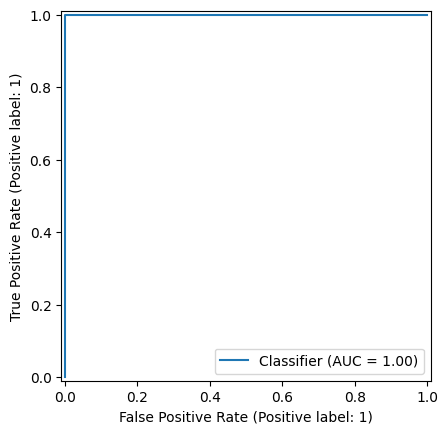

In [80]:
RocCurveDisplay.from_predictions(
    y_true,
    probs[:,1]
)

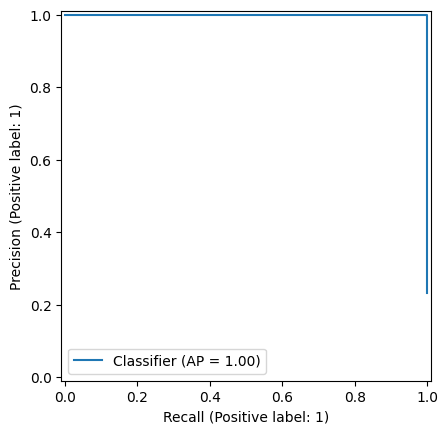

In [82]:
PrecisionRecallDisplay.from_predictions(
    y_true,
    probs[:,1]
)

In [89]:
# true responces
display(
    check_df.loc[check_df["label"] == 0,
                 ["prompt_text", "response", "label"]]
    .sample(20, random_state=42)
)

,prompt_text,response,label
98294,what is anaphylaxis?,"a severe, potentially life-threatening allergic reaction involving massive histamine release causing airway constriction, hypotension, and shock",0
24290,who co-founded apple inc.?,"steve jobs, steve wozniak, and ronald wayne",0
55568,what is crispr's potential application in medicine?,"treating genetic diseases by correcting mutations in dna, with trials in progress for sickle cell disease, beta-thalassemia, and certain cancers",0
45062,what is the atomic number of carbon?,6,0
15178,what programming language is primarily used for ios development?,swift,0
60351,what is the difference between rna interference (rnai) and crispr?,rnai silences gene expression post-transcriptionally using small rna molecules without altering dna; crispr directly edits the dna sequence,0
26324,what is backpropagation?,an algorithm for training neural networks by computing gradients of the loss function with respect to each weight using the chain rule,0
55975,what does ram stand for?,random access memory,0
23405,what is herd immunity?,"when a sufficient proportion of a population has become immune to an infection (through vaccination or prior infection) that it reduces disease spread, protecting those not immune",0
85366,what year was the gpt-3 model released?,2020,0


In [86]:
# hallucinated
display(
    check_df.loc[check_df["label"] == 1,
                 ["prompt_text", "response", "label"]]
    .sample(20, random_state=42)
)

,prompt_text,response,label
98013,what is the difference between sensitivity and specificity in diagnostic testing?,gram-positive bacteria have an outer lipopolysaccharide membrane,1
66847,what is the role of the softmax function in classification?,quantum computers use classical bits in superposition,1
60666,what is the role of regulatory t cells (tregs)?,gram-positive bacteria have an outer lipopolysaccharide membrane,1
117359,what is the process of meiosis?,apoptosis is always triggered by external pathogens,1
61922,who co-founded apple inc.?,the transformer model was introduced in 2018,1
9110,what is anaphylaxis?,gram-positive bacteria have an outer lipopolysaccharide membrane,1
20141,what is herd immunity?,sepsis is defined as an infection accompanied by fever,1
15146,what is the function of the kidneys?,regulatory t cells activate other immune cells,1
46808,what is the role of atp in cells?,quantum entanglement allows faster-than-light communication,1
92530,what is the complement system?,regulatory t cells activate other immune cells,1


In [88]:
display(
    check_df.loc[
        check_df["label"] == 1,
        ["prompt_text", "response"]
    ].head(50)
)

,prompt_text,response
13,what is the difference between supervised and unsupervised learning?,gpt-3 was released in 2019
18,what is a convolutional neural network (cnn) primarily used for?,gpt-3 was released in 2019
23,what is docker used for?,gpt-3 was released in 2019
25,what is the difference between a process and a thread?,gpt-3 was released in 2019
27,what is the vanishing gradient problem in deep neural networks?,gpt-3 was released in 2019
50,what is the hubble constant?,"carbon-14 has a half-life of approximately 4,500 years"
59,what is the observer effect in quantum mechanics?,"carbon-14 has a half-life of approximately 4,500 years"
60,what is the role of telomeres?,"carbon-14 has a half-life of approximately 4,500 years"
66,what is the function of red blood cells?,statins inhibit cox-2 enzymes to reduce cholesterol
84,what is a monoclonal antibody?,statins inhibit cox-2 enzymes to reduce cholesterol


**The analysis showed that hallucinated responses are usually paired with unrelated questions. As a result, BERT mainly learns to detect semantic mismatch between the question and the answer rather than subtle factual errors. This likely explains the perfect evaluation metrics.**

In [95]:
uploaded = files.upload()

Saving lightgbm_final_pipeline.pkl to lightgbm_final_pipeline.pkl


In [96]:
lgb_pipeline = joblib.load("lightgbm_final_pipeline.pkl")

In [97]:
# prediction
y_pred_lgb = lgb_pipeline.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [98]:
# class 1 probability
y_prob_lgb = lgb_pipeline.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_lgb))
print("Precision:", precision_score(y_test, y_pred_lgb))
print("Recall   :", recall_score(y_test, y_pred_lgb))
print("F1       :", f1_score(y_test, y_pred_lgb))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_lgb))

Accuracy : 0.9629629629629629
Precision: 0.8621538461538462
Recall   : 1.0
F1       : 0.9259748843357568
ROC-AUC  : 1.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


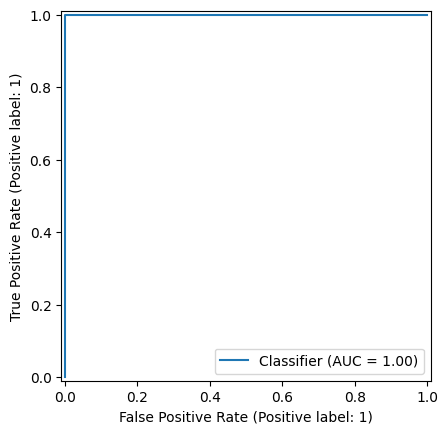

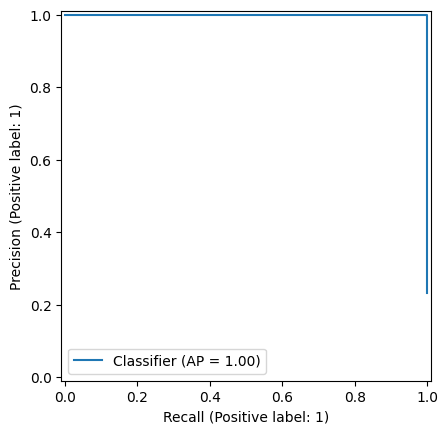

In [99]:
RocCurveDisplay.from_predictions(y_test, y_prob_lgb)

PrecisionRecallDisplay.from_predictions(y_test, y_prob_lgb)

In [100]:
print(np.min(y_prob_lgb))
print(np.max(y_prob_lgb))

print(np.unique(np.round(y_prob_lgb, 5))[:20])

1.7849687685484595e-05
0.9999864257829828
[2.0000e-05 3.0000e-05 4.0000e-05 6.0000e-05 7.0000e-05 1.1000e-04
 1.2000e-04 2.6000e-04 8.3000e-04 2.1200e-03 5.3650e-02 9.9857e-01
 9.9959e-01 9.9964e-01 9.9966e-01 9.9968e-01 9.9969e-01 9.9971e-01
 9.9983e-01 9.9984e-01]


In [101]:
print(y_prob_lgb[:20])

[4.22207270e-05 4.22207270e-05 1.06930973e-04 2.56322444e-04
 2.42387324e-05 8.32212615e-04 9.99923023e-01 2.11545513e-03
 6.06816486e-05 1.22473364e-04 2.98212940e-05 1.88838449e-05
 1.78496877e-05 4.39619867e-05 6.04559351e-05 9.98566314e-01
 5.36484130e-02 2.88968661e-05 3.92863568e-05 9.99975030e-01]


In [102]:
print(confusion_matrix(y_test, y_pred_lgb))

[[22115  1120]
 [    0  7005]]


In [106]:
comparison.style\
    .hide(axis="index")\
    .format({
        "LightGBM": "{:.3f}",
        "BERT": "{:.3f}"
    })

Metric,LightGBM,BERT
Accuracy,0.963,1.000
Precision,0.862,1.000
Recall,1.000,1.000
F1-score,0.926,1.000
ROC-AUC,1.000,1.000


*The comparison shows that BERT outperformed LightGBM on the main evaluation metrics. BERT achieved perfect Accuracy, Precision, and F1-score, while both models reached the same Recall and ROC-AUC.

Additional analysis showed that hallucinated responses in the dataset are usually paired with unrelated questions rather than subtle factual mistakes. As a result, BERT effectively learned the semantic relationship between the question and the response, which explains its superior performance.

Based on these experimental results, BERT was selected as the final model for deployment. It provides the best overall performance for the hallucination detection task and is better suited for capturing semantic inconsistencies between questions and responses.***

In [107]:
!pip freeze > requirements.txt